# Imports

In [1]:
import os
import torch
import numpy as np
import open3d as o3d
from random import randint
from utils.loss_utils import l1_loss, ssim
from gaussian_renderer import render, network_gui
import sys
from scene import Scene, GaussianModel
from utils.general_utils import safe_state, get_expon_lr_func
import uuid
from tqdm import tqdm
from utils.image_utils import psnr
from argparse import ArgumentParser, Namespace
from arguments import ModelParams, PipelineParams, OptimizationParams
from scene.dataset_readers import sceneLoadTypeCallbacks
try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_FOUND = True
except ImportError:
    TENSORBOARD_FOUND = False

try:
    from fused_ssim import fused_ssim
    FUSED_SSIM_AVAILABLE = True
except:
    FUSED_SSIM_AVAILABLE = False

try:
    from diff_gaussian_rasterization import SparseGaussianAdam
    SPARSE_ADAM_AVAILABLE = True
except:
    SPARSE_ADAM_AVAILABLE = False

def prepare_output_and_logger(args):    
    if not args.model_path:
        if os.getenv('OAR_JOB_ID'):
            unique_str=os.getenv('OAR_JOB_ID')
        else:
            unique_str = str(uuid.uuid4())
        args.model_path = os.path.join("./output/", unique_str[0:10])
        
    # Set up output folder
    print("Output folder: {}".format(args.model_path))
    os.makedirs(args.model_path, exist_ok = True)
    with open(os.path.join(args.model_path, "cfg_args"), 'w') as cfg_log_f:
        cfg_log_f.write(str(Namespace(**vars(args))))

    # Create Tensorboard writer
    tb_writer = None
    if TENSORBOARD_FOUND:
        tb_writer = SummaryWriter(args.model_path)
    else:
        print("Tensorboard not available: not logging progress")
    return tb_writer



def training_report(tb_writer, iteration, Ll1, loss, l1_loss, elapsed, testing_iterations, scene : Scene, renderFunc, renderArgs, train_test_exp):
    if tb_writer:
        tb_writer.add_scalar('train_loss_patches/l1_loss', Ll1.item(), iteration)
        tb_writer.add_scalar('train_loss_patches/total_loss', loss.item(), iteration)
        tb_writer.add_scalar('iter_time', elapsed, iteration)

    # Report test and samples of training set
    if iteration in testing_iterations:
        torch.cuda.empty_cache()
        validation_configs = ({'name': 'test', 'cameras' : scene.getTestCameras()}, 
                              {'name': 'train', 'cameras' : [scene.getTrainCameras()[idx % len(scene.getTrainCameras())] for idx in range(5, 30, 5)]})

        for config in validation_configs:
            if config['cameras'] and len(config['cameras']) > 0:
                l1_test = 0.0
                psnr_test = 0.0
                for idx, viewpoint in enumerate(config['cameras']):
                    image = torch.clamp(renderFunc(viewpoint, scene.gaussians, *renderArgs)["render"], 0.0, 1.0)
                    gt_image = torch.clamp(viewpoint.original_image.to("cuda"), 0.0, 1.0)
                    if train_test_exp:
                        image = image[..., image.shape[-1] // 2:]
                        gt_image = gt_image[..., gt_image.shape[-1] // 2:]
                    if tb_writer and (idx < 5):
                        tb_writer.add_images(config['name'] + "_view_{}/render".format(viewpoint.image_name), image[None], global_step=iteration)
                        if iteration == testing_iterations[0]:
                            tb_writer.add_images(config['name'] + "_view_{}/ground_truth".format(viewpoint.image_name), gt_image[None], global_step=iteration)
                    l1_test += l1_loss(image, gt_image).mean().double()
                    psnr_test += psnr(image, gt_image).mean().double()
                psnr_test /= len(config['cameras'])
                l1_test /= len(config['cameras'])          
                print("\n[ITER {}] Evaluating {}: L1 {} PSNR {}".format(iteration, config['name'], l1_test, psnr_test))
                if tb_writer:
                    tb_writer.add_scalar(config['name'] + '/loss_viewpoint - l1_loss', l1_test, iteration)
                    tb_writer.add_scalar(config['name'] + '/loss_viewpoint - psnr', psnr_test, iteration)

        if tb_writer:
            tb_writer.add_histogram("scene/opacity_histogram", scene.gaussians.get_opacity, iteration)
            tb_writer.add_scalar('total_points', scene.gaussians.get_xyz.shape[0], iteration)
        torch.cuda.empty_cache()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# Parser Setting

In [2]:
parser = ArgumentParser(description="Training script parameters")
lp = ModelParams(parser)
op = OptimizationParams(parser)
pp = PipelineParams(parser)
parser.add_argument('--ip', type=str, default="127.0.0.1")
parser.add_argument('--port', type=int, default=6009)
parser.add_argument('--debug_from', type=int, default=-1)
parser.add_argument('--detect_anomaly', action='store_true', default=False)
parser.add_argument("--test_iterations", nargs="+", type=int, default=[7_000, 30_000])
parser.add_argument("--save_iterations", nargs="+", type=int, default=[7_000, 30_000])
parser.add_argument("--quiet", action="store_true")
parser.add_argument('--disable_viewer', action='store_true', default=False)
parser.add_argument("--checkpoint_iterations", nargs="+", type=int, default=[])
parser.add_argument("--start_checkpoint", type=str, default=None)

# In Jupyter, parse_known_args avoids runtime arguments such as -f that are injected by the notebook kernel.
args, _ = parser.parse_known_args([])
args.save_iterations.append(args.iterations)

# Convert the parser namespace into the lightweight argument objects used by the training code.
model_args = lp.extract(args)
opt_args = op.extract(args)
pipe_args = pp.extract(args)
model_args.source_path = os.path.join(model_args.source_path,"GaussianTest/Test2") 
# source_path is hardcoded on purpose for this tutorial, but you can change it to your own dataset path.

print("Loaded parser-backed arguments")
print("sh_degree:", model_args.sh_degree)
print("optimizer_type:", opt_args.optimizer_type)
print("source path: ", model_args.source_path)

Loaded parser-backed arguments
sh_degree: 3
optimizer_type: default
source path:  c:\Dev\gaussian-splatting-for-practice\GaussianTest/Test2


# Setup Before Training

In [3]:
first_iter = 0
tb_writer = prepare_output_and_logger(model_args)
gaussians = GaussianModel(model_args.sh_degree, opt_args.optimizer_type)
scene1 = Scene(model_args, gaussians)
gaussians.training_setup(opt_args)
if args.checkpoint_iterations:
    (model_params, first_iter) = torch.load(args.checkpoint)
    gaussians.restore(model_params, opt_args)

bg_color = [1, 1, 1] if model_args.white_background else [0, 0, 0]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")

iter_start = torch.cuda.Event(enable_timing = True)
iter_end = torch.cuda.Event(enable_timing = True)

use_sparse_adam = opt_args.optimizer_type == "sparse_adam" and SPARSE_ADAM_AVAILABLE 
depth_l1_weight = get_expon_lr_func(opt_args.depth_l1_weight_init, opt_args.depth_l1_weight_final, max_steps=opt_args.iterations)

viewpoint_stack = scene1.getTrainCameras().copy()
viewpoint_indices = list(range(len(viewpoint_stack)))
ema_loss_for_log = 0.0
ema_Ll1depth_for_log = 0.0

progress_bar = tqdm(range(first_iter, opt_args.iterations), desc="Training progress")
first_iter += 1

Output folder: ./output/566780ea-7
Tensorboard not available: not logging progress
Reading camera 25/25
Loading Training Cameras


c:\Users\COM\anaconda3\envs\gaussian_splatting\lib\site-packages\torch\cuda\__init__.py:218: UserWarning: 
NVIDIA GeForce RTX 5080 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5080 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


Loading Test Cameras
Number of points at initialisation :  1768


Training progress:   0%|          | 0/30000 [00:00<?, ?it/s]

# Start Training

In [4]:
for iteration in range(first_iter, 601):
    iter_start.record()
    
    gaussians.update_learning_rate(iteration)
    
    # Every 1000 its we increase the levels of SH up to a maximum degree
    if iteration % 1000 == 0:
        gaussians.oneupSHdegree()
    
    # Pick a random Camera
    if not viewpoint_stack:
        viewpoint_stack = scene1.getTrainCameras().copy()
        viewpoint_indices = list(range(len(viewpoint_stack)))
    rand_idx = randint(0, len(viewpoint_indices) - 1)
    viewpoint_cam = viewpoint_stack.pop(rand_idx)
    vind = viewpoint_indices.pop(rand_idx)
    
    # Render
    if (iteration - 1) == args.debug_from:
        pipe_args.debug = True
    
    bg = torch.rand((3), device="cuda") if opt_args.random_background else background
    
    render_pkg = render(viewpoint_cam, gaussians, pipe_args, bg, use_trained_exp=model_args.train_test_exp, separate_sh=SPARSE_ADAM_AVAILABLE)
    image, viewspace_point_tensor, visibility_filter, radii = render_pkg["render"], render_pkg["viewspace_points"], render_pkg["visibility_filter"], render_pkg["radii"]
    
    if viewpoint_cam.alpha_mask is not None:
        alpha_mask = viewpoint_cam.alpha_mask.cuda()
        image *= alpha_mask
    
    # Loss
    gt_image = viewpoint_cam.original_image.cuda()
    Ll1 = l1_loss(image, gt_image)
    if FUSED_SSIM_AVAILABLE:
        ssim_value = fused_ssim(image.unsqueeze(0), gt_image.unsqueeze(0))
    else:
        ssim_value = ssim(image, gt_image)
    
    loss = (1.0 - opt_args.lambda_dssim) * Ll1 + opt_args.lambda_dssim * (1.0 - ssim_value)
    
    # Depth regularization
    Ll1depth_pure = 0.0
    if depth_l1_weight(iteration) > 0 and viewpoint_cam.depth_reliable:
        invDepth = render_pkg["depth"]
        mono_invdepth = viewpoint_cam.invdepthmap.cuda()
        depth_mask = viewpoint_cam.depth_mask.cuda()
    
        Ll1depth_pure = torch.abs((invDepth  - mono_invdepth) * depth_mask).mean()
        Ll1depth = depth_l1_weight(iteration) * Ll1depth_pure 
        loss += Ll1depth
        Ll1depth = Ll1depth.item()
    else:
        Ll1depth = 0
    
    loss.backward()
    
    iter_end.record()
    
    with torch.no_grad():
        # Progress bar
        ema_loss_for_log = 0.4 * loss.item() + 0.6 * ema_loss_for_log
        ema_Ll1depth_for_log = 0.4 * Ll1depth + 0.6 * ema_Ll1depth_for_log
    
        if iteration % 10 == 0:
            progress_bar.set_postfix({"Loss": f"{ema_loss_for_log:.{7}f}", "Depth Loss": f"{ema_Ll1depth_for_log:.{7}f}"})
            progress_bar.update(10)
        if iteration == opt_args.iterations:
            progress_bar.close()
    
        # Log and save
        training_report(tb_writer, iteration, Ll1, loss, l1_loss, iter_start.elapsed_time(iter_end), args.test_iterations, scene1, render, (pipe_args, background, 1., SPARSE_ADAM_AVAILABLE, None, model_args.train_test_exp), model_args.train_test_exp)
        if (iteration in args.save_iterations):
            print("\n[ITER {}] Saving Gaussians".format(iteration))
            scene1.save(iteration)
    
        # Densification
        if iteration < opt_args.densify_until_iter:
            # Keep track of max radii in image-space for pruning
            gaussians.max_radii2D[visibility_filter] = torch.max(gaussians.max_radii2D[visibility_filter], radii[visibility_filter])
            gaussians.add_densification_stats(viewspace_point_tensor, visibility_filter)
            check_grads = gaussians.xyz_gradient_accum # not inside train.py
            check_xyzs = gaussians.get_xyz # not inside train.py
            check_scaling = gaussians.get_scaling # not inside train.py
            check_opacity= gaussians.get_opacity # not inside train.py
            check_rotation= gaussians._rotation # not inside train.py
            check_denom = gaussians.denom # not inside train.py
    
            if iteration > opt_args.densify_from_iter and iteration % opt_args.densification_interval == 0:
                size_threshold = 20 if iteration > opt_args.opacity_reset_interval else None
                gaussians.densify_and_prune(opt_args.densify_grad_threshold, 0.005, scene1.cameras_extent, size_threshold, radii)
                
    
            if iteration % opt_args.opacity_reset_interval == 0 or (model_args.white_background and iteration == opt_args.densify_from_iter):
                gaussians.reset_opacity()

        # Optimizer step
        if iteration < opt_args.iterations:
            gaussians.exposure_optimizer.step()
            gaussians.exposure_optimizer.zero_grad(set_to_none = True)
            if use_sparse_adam:
                visible = radii > 0
                gaussians.optimizer.step(visible, radii.shape[0])
                gaussians.optimizer.zero_grad(set_to_none = True)
            else:
                gaussians.optimizer.step()
                gaussians.optimizer.zero_grad(set_to_none = True)
        
        if (iteration in args.checkpoint_iterations):
            print("\n[ITER {}] Saving Checkpoint".format(iteration))
            torch.save((gaussians.capture(), iteration), scene1.model_path + "/chkpnt" + str(iteration) + ".pth")

Training progress:   2%|▏         | 600/30000 [00:18<13:50, 35.42it/s, Loss=0.0931000, Depth Loss=0.0000000] 

--- 증식 전 총 가우시안: 1768 ---
 복제(Clone)된 가우시안 개수: 9
Clone 직후 총 가우시안: 1777
 분할(Split)된 원본 가우시안 개수: 525 (이것이 2배로 쪼개짐)
Split 직후 총 가우시안: 2302
Prune 직후 최종 가우시안: 2302


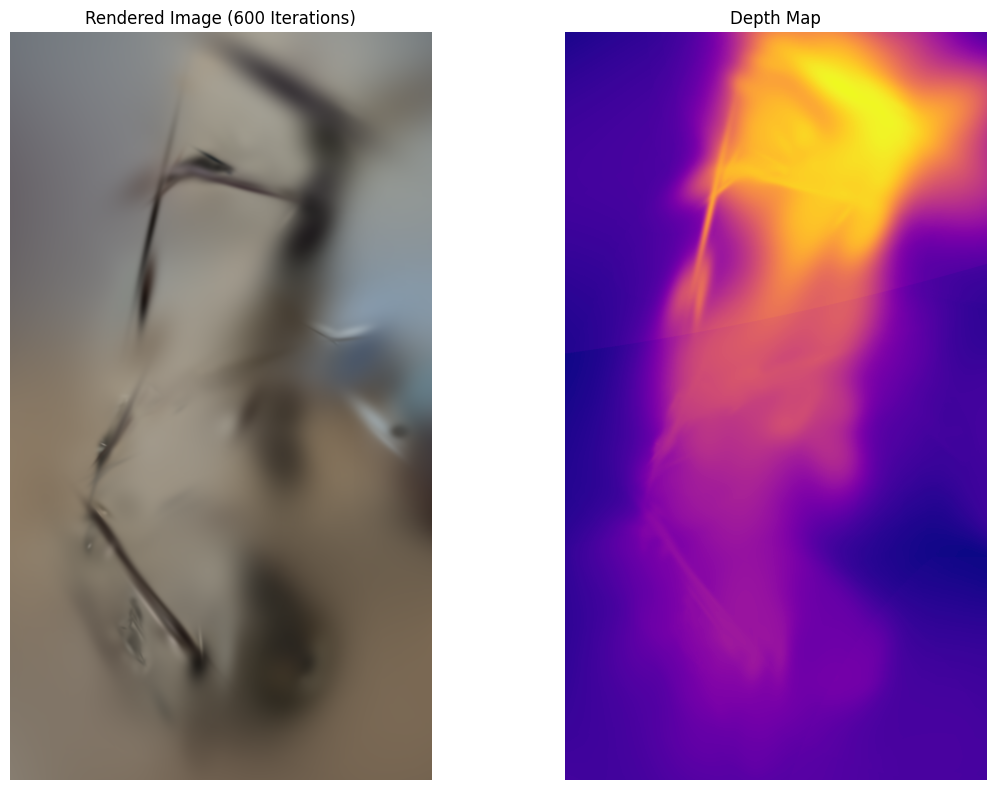

In [5]:
import matplotlib.pyplot as plt

rgb = image.detach().cpu().numpy().transpose(1, 2, 0)
rgb = rgb.clip(0, 1)

depth = render_pkg["depth"].detach().cpu().numpy()
if depth.ndim == 3 and depth.shape[0] == 1:
    depth = depth.squeeze(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

axes[0].imshow(rgb)
axes[0].set_title("Rendered Image (600 Iterations)")
axes[0].axis("off")

axes[1].imshow(depth, cmap="plasma")
axes[1].set_title("Depth Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Copying and Pruning

The cell below shows the ellipsoid of where the first gaussian is set.  

check_grads, check_xyzs, check_scaling, check_opacity, check_rotation, check_denom are datas before last iteration.

And now I'm going to check which gaussians will be copied or splitted

Let's find gaussians that are going to be copied

In [6]:
real_grad = check_grads/check_denom
real_grad[real_grad.isnan()] = 0.0
find_grads=torch.norm(real_grad,dim=-1)

Gaussians below are going to be copied

## densify_and_clone
```python
def densify_and_clone(self, grads, grad_threshold, scene_extent):
    # Extract points that satisfy the gradient condition
    selected_pts_mask = torch.where(torch.norm(grads, dim=-1) >= grad_threshold, True, False)
    selected_pts_mask = torch.logical_and(selected_pts_mask,
                                                torch.max(self.get_scaling, dim=1).values <= self.percent_dense*scene_extent)
    ...
```
you find whether its gradient is bigger than grad_threshold(==opt.densify_grad_threshold: 0.0002) and

In [7]:
cond1 = find_grads>opt_args.densify_grad_threshold
cond2 = torch.max(check_scaling, dim=1).values <= gaussians.percent_dense*scene1.cameras_extent
combined_cond = cond1&cond2
selected_indices = combined_cond.nonzero(as_tuple = True)[0]
print(len(selected_indices))
print(selected_indices)
index=selected_indices[0]

9
tensor([ 161,  380,  821,  828,  844,  870, 1016, 1600, 1729], device='cuda:0')


In [8]:
print(opt_args.densify_grad_threshold)

0.0002


In [9]:
print(f"grad bigger than threshold: {cond1[index]}")

grad bigger than threshold: True


In [10]:
print(f"Scale smaller than threshold: {cond2[index]}")

Scale smaller than threshold: True


In [11]:
# Visualize Gaussian ellipsoids in 3D with Vispy
import numpy as np
from vispy import scene, app
from vispy.visuals.transforms import MatrixTransform
from utils.general_utils import build_rotation

# app.use_app('jupyter_rfb')

points = check_xyzs[index].detach().cpu().numpy()
scales = check_scaling[index].detach().cpu().numpy()
opacities = check_opacity[index].detach().cpu().numpy().squeeze()
rotations = build_rotation(check_rotation)[index].detach().cpu().numpy()


from vispy.geometry import create_sphere
sphere = create_sphere(rows=24, cols=24, radius=1.0)
vertices = sphere.get_vertices()
faces = sphere.get_faces()


canvas = scene.SceneCanvas(keys='interactive', show=True, bgcolor='white', title='Gaussian Ellipsoids')
view = canvas.central_widget.add_view()
view.camera = 'arcball'
view.camera.fov = 45
view.camera.distance = 30

#for p, s, o, R in zip(points, scales, opacities, rotations):
transform = MatrixTransform()
matrix = np.eye(4, dtype=np.float32)
matrix[:3, :3] = rotations @ np.diag(scales.astype(np.float32))
matrix[:3, 3] = points.astype(np.float32)
transform.matrix = matrix.T

color = (0.2, 0.6, 1.0, float(np.clip(opacities, 0.05, 1.0)))
mesh = scene.visuals.Mesh(vertices=vertices, faces=faces, color=color, shading='smooth', parent=view.scene)
mesh.transform = transform

axis = scene.visuals.XYZAxis(parent=view.scene)
canvas

RFBOutputContext()

This gaussian is going to be cloned.(it's so small so it is shown like a dot)

## densify_and_split

```python
def densify_and_split(self, grads, grad_threshold, scene_extent, N=2):
    n_init_points = self.get_xyz.shape[0]
    # Extract points that satisfy the gradient condition
    padded_grad = torch.zeros((n_init_points), device="cuda")
    padded_grad[:grads.shape[0]] = grads.squeeze()
    selected_pts_mask = torch.where(padded_grad >= grad_threshold, True, False)
    selected_pts_mask = torch.logical_and(selected_pts_mask,
                                              torch.max(self.get_scaling, dim=1).values > self.percent_dense*scene_extent)
    ...
```

In [12]:
cond3 = torch.max(check_scaling, dim=1).values > gaussians.percent_dense*scene1.cameras_extent
combined_cond2 = cond1&cond3
selected_indices2 = combined_cond2.nonzero(as_tuple = True)[0]
print(len(selected_indices2))
print(selected_indices2)

525
tensor([   2,    6,    9,   10,   12,   18,   21,   28,   30,   34,   37,   41,
          47,   48,   53,   62,   64,   65,   71,   73,   77,   80,   89,   96,
          99,  104,  107,  109,  123,  126,  128,  136,  142,  148,  152,  163,
         164,  166,  172,  175,  176,  180,  182,  184,  185,  187,  190,  192,
         196,  197,  205,  210,  215,  217,  218,  221,  231,  236,  256,  259,
         282,  289,  290,  302,  304,  308,  310,  313,  321,  322,  330,  333,
         334,  347,  349,  350,  352,  359,  377,  389,  391,  392,  394,  396,
         398,  405,  407,  419,  420,  441,  443,  449,  451,  454,  458,  460,
         461,  464,  465,  469,  473,  478,  484,  485,  488,  490,  492,  497,
         503,  505,  510,  512,  537,  539,  544,  550,  551,  553,  555,  558,
         571,  586,  588,  592,  595,  597,  600,  604,  605,  608,  611,  612,
         615,  618,  631,  636,  637,  638,  639,  644,  650,  652,  657,  661,
         664,  668,  672,  673,  680

In [13]:
print(f"grad bigger than threshold: {cond1[index]}")
print(f"Scale smaller than threshold: {cond3[index]}")

grad bigger than threshold: True
Scale smaller than threshold: False


In [14]:
index=selected_indices2[0]

points = check_xyzs[index].detach().cpu().numpy()
scales = check_scaling[index].detach().cpu().numpy()
opacities = check_opacity[index].detach().cpu().numpy().squeeze()
rotations = build_rotation(check_rotation)[index].detach().cpu().numpy()


from vispy.geometry import create_sphere
sphere = create_sphere(rows=24, cols=24, radius=1.0)
vertices = sphere.get_vertices()
faces = sphere.get_faces()


canvas = scene.SceneCanvas(keys='interactive', show=True, bgcolor='white', title='Gaussian Ellipsoids')
view = canvas.central_widget.add_view()
view.camera = 'arcball'
view.camera.fov = 45
view.camera.distance = 30

#for p, s, o, R in zip(points, scales, opacities, rotations):
transform = MatrixTransform()
matrix = np.eye(4, dtype=np.float32)
matrix[:3, :3] = rotations @ np.diag(scales.astype(np.float32))
matrix[:3, 3] = points.astype(np.float32)
transform.matrix = matrix.T

color = (0.2, 0.6, 1.0, float(np.clip(opacities, 0.05, 1.0)))
mesh = scene.visuals.Mesh(vertices=vertices, faces=faces, color=color, shading='smooth', parent=view.scene)
mesh.transform = transform

axis = scene.visuals.XYZAxis(parent=view.scene)
canvas

RFBOutputContext()

This gaussian will be splitted.

In [15]:
xyz = gaussians.get_xyz
scaling = gaussians.get_scaling
opacity = gaussians.get_opacity
rotation = gaussians.get_rotation
n_gaussians = xyz.shape[0]
sample_idx = torch.randperm(n_gaussians, device=xyz.device)[:100]
points = xyz[sample_idx].detach().cpu().numpy()
scales = scaling[sample_idx].detach().cpu().numpy()
opacities = opacity[sample_idx].detach().cpu().numpy().squeeze()
rotations = build_rotation(rotation[sample_idx]).detach().cpu().numpy()
sphere = create_sphere(rows=24, cols=24, radius=1.0)
vertices = sphere.get_vertices()
faces = sphere.get_faces()
canvas = scene.SceneCanvas(keys="interactive", show=True, bgcolor="white", title="Sampled Gaussian Ellipsoids (100)")
view = canvas.central_widget.add_view()
view.camera = "arcball"
view.camera.fov = 45
view.camera.center = points.mean(axis=0)
view.camera.distance = 30
for p, s, o, R in zip(points, scales, opacities, rotations):
    transform = MatrixTransform()
    matrix = np.eye(4, dtype=np.float32)
    matrix[:3, :3] = R @ np.diag(s.astype(np.float32))
    matrix[:3, 3] = p.astype(np.float32)
    transform.matrix = matrix.T
    color = (0.2, 0.6, 1.0, float(np.clip(o, 0.05, 1.0)))
    mesh = scene.visuals.Mesh(vertices=vertices, faces=faces, color=color, shading="smooth", parent=view.scene)
    mesh.transform = transform
axis = scene.visuals.XYZAxis(parent=view.scene)
canvas

RFBOutputContext()

# Actual Mathematics

In [16]:
import math
import numpy as np
import torch
from utils.general_utils import build_rotation
from utils.sh_utils import eval_sh

torch.set_printoptions(precision=6, sci_mode=False, linewidth=140)
np.set_printoptions(precision=6, suppress=True, linewidth=140)

print("=" * 78)
print("Cell 1: Target selection & attribute extraction")
print("Largest 3D Gaussian after 600 training iterations")
print("=" * 78)

scales_after_600 = gaussians.get_scaling
largest_idx = int(torch.argmax(torch.max(scales_after_600, dim=-1).values).item())

xyz = gaussians.get_xyz[largest_idx].detach()
scale_vec = scales_after_600[largest_idx].detach()          # S as (s_x, s_y, s_z)
quat = gaussians.get_rotation[largest_idx].detach()         # quaternion (w, x, y, z)
opacity_o = gaussians.get_opacity[largest_idx].detach()

xyz_np = xyz.cpu().numpy()
scale_np = scale_vec.cpu().numpy()
quat_np = quat.cpu().numpy()
opacity_o_f = float(opacity_o.cpu())

print(f"\nTotal Gaussians after 600 iters: {scales_after_600.shape[0]}")
print(f"Largest index (argmax of max-axis scale): {largest_idx}")
print(f"  max(s_x, s_y, s_z) = {float(scale_vec.max()):.6f}")
print(f"  volume s_x*s_y*s_z  = {float(scale_vec.prod()):.6f}")

print("\n--- Position xyz (3,) ---")
print("torch:", xyz)
print("numpy:", xyz_np)

print("\n--- Scaling S (3,)  raw axis lengths before forming diag(S) ---")
print("torch:", scale_vec)
print("numpy:", scale_np)

print("\n--- Rotation quaternion R (4,)  stored as (w, x, y, z) ---")
print("torch:", quat)
print("numpy:", quat_np)
print(f"quaternion norm = {float(quat.norm()):.6f}")

print("\n--- Opacity o (scalar) ---")
print("torch:", opacity_o)
print(f"numpy: {opacity_o_f:.8f}")
print("=" * 78)


Cell 1: Target selection & attribute extraction
Largest 3D Gaussian after 600 training iterations

Total Gaussians after 600 iters: 2302
Largest index (argmax of max-axis scale): 1530
  max(s_x, s_y, s_z) = 7.386565
  volume s_x*s_y*s_z  = 43.614609

--- Position xyz (3,) ---
torch: tensor([-11.541831,  15.395939,   4.253773], device='cuda:0')
numpy: [-11.541831  15.395939   4.253773]

--- Scaling S (3,)  raw axis lengths before forming diag(S) ---
torch: tensor([1.745721, 7.386565, 3.382320], device='cuda:0')
numpy: [1.745721 7.386565 3.38232 ]

--- Rotation quaternion R (4,)  stored as (w, x, y, z) ---
torch: tensor([ 0.951858, -0.283840,  0.004326,  0.115681], device='cuda:0')
numpy: [ 0.951858 -0.28384   0.004326  0.115681]
quaternion norm = 1.000000

--- Opacity o (scalar) ---
torch: tensor([0.796977], device='cuda:0')
numpy: 0.79697728


Cell 2: Step 1 — 3D covariance   Sigma = R S S^T R^T

Formula:  Sigma = R S S^T R^T
  S = diag(s_x, s_y, s_z)
  R = rotation matrix built from quaternion (w, x, y, z)

--- Scaling matrix S (3x3) ---
[[1.745721 0.       0.      ]
 [0.       7.386565 0.      ]
 [0.       0.       3.38232 ]]
shape = (3, 3)

--- Rotation matrix R (3x3) ---
[[ 0.973199 -0.222679 -0.057434]
 [ 0.217767  0.812106  0.541351]
 [-0.073905 -0.53935   0.838833]]
shape = (3, 3)
R^T R (should be ~ I):
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
det(R) = 1.000000

--- Intermediate S S^T (3x3) ---
[[ 3.04754   0.        0.      ]
 [ 0.       54.561344  0.      ]
 [ 0.        0.       11.440088]]

--- 3D covariance Sigma = R S S^T R^T  (3x3) ---
[[  5.629579  -9.576633   5.782561]
 [ -9.576632  39.481266 -18.752436]
 [  5.782561 -18.752434  23.938137]]
shape = (3, 3)
symmetric? max |Sigma - Sigma^T| = 1.907e-06
eigenvalues of Sigma = [ 3.047541 11.440088 54.56135 ]
sqrt(eigenvalues) should match scaling [1.745721 3.

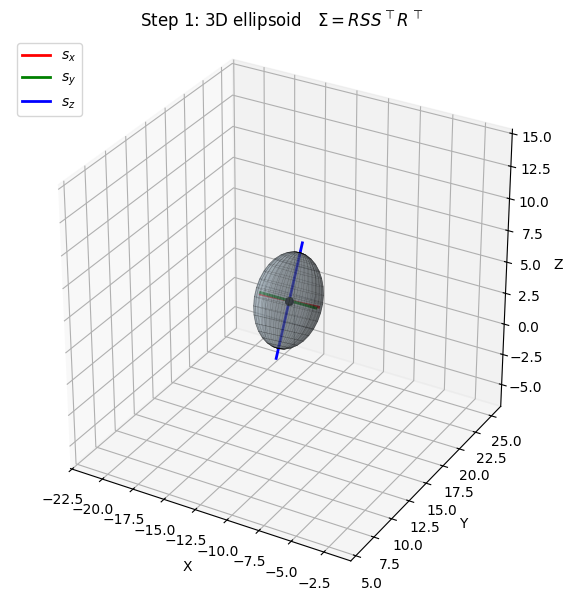

In [17]:
import matplotlib.pyplot as plt

print("=" * 78)
print("Cell 2: Step 1 — 3D covariance   Sigma = R S S^T R^T")
print("=" * 78)

# Scaling 3x3 and rotation 3x3 from the values extracted in Cell 1
S_mat = np.diag(scale_np)
R_mat = build_rotation(quat.unsqueeze(0))[0].detach().cpu().numpy()
Sigma = R_mat @ S_mat @ S_mat.T @ R_mat.T

print("\nFormula:  Sigma = R S S^T R^T")
print("  S = diag(s_x, s_y, s_z)")
print("  R = rotation matrix built from quaternion (w, x, y, z)")

print("\n--- Scaling matrix S (3x3) ---")
print(S_mat)
print(f"shape = {S_mat.shape}")

print("\n--- Rotation matrix R (3x3) ---")
print(R_mat)
print(f"shape = {R_mat.shape}")
print("R^T R (should be ~ I):\n", R_mat.T @ R_mat)
print(f"det(R) = {np.linalg.det(R_mat):.6f}")

print("\n--- Intermediate S S^T (3x3) ---")
SST = S_mat @ S_mat.T
print(SST)

print("\n--- 3D covariance Sigma = R S S^T R^T  (3x3) ---")
print(Sigma)
print(f"shape = {Sigma.shape}")
print(f"symmetric? max |Sigma - Sigma^T| = {np.abs(Sigma - Sigma.T).max():.3e}")
eig_3d, _ = np.linalg.eigh(Sigma)
print(f"eigenvalues of Sigma = {eig_3d}")
print(f"sqrt(eigenvalues) should match scaling {np.sort(scale_np)}")

# SH color for the 3D plot
sh_one = gaussians.get_features[largest_idx].T.unsqueeze(0)
direction = xyz - viewpoint_cam.camera_center
direction = direction / (direction.norm() + 1e-8)
rgb_color = eval_sh(gaussians.active_sh_degree, sh_one, direction.view(1, 3))
rgb_color = torch.clamp_min(rgb_color + 0.5, 0.0).squeeze().detach().cpu().numpy()
print("\n--- SH color of this Gaussian (for visualization) ---")
print(rgb_color)

# 3D ellipsoid: unit sphere scaled by S, rotated by R, translated by xyz
u = np.linspace(0, 2 * np.pi, 36)
v = np.linspace(0, np.pi, 18)
sphere = np.stack([
    np.outer(np.cos(u), np.sin(v)).ravel(),
    np.outer(np.sin(u), np.sin(v)).ravel(),
    np.outer(np.ones_like(u), np.cos(v)).ravel(),
], axis=0)
ell = (R_mat @ (scale_np[:, None] * sphere)) + xyz_np[:, None]
n_u, n_v = len(u), len(v)
X, Y, Z = ell[0].reshape(n_u, n_v), ell[1].reshape(n_u, n_v), ell[2].reshape(n_u, n_v)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, color=np.clip(rgb_color, 0, 1), alpha=0.45, linewidth=0)
ax.plot_wireframe(X, Y, Z, color="k", linewidth=0.25, alpha=0.35)
axis_len = scale_np * 1.2
for k, c, lab in zip(range(3), ["r", "g", "b"], [r"$s_x$", r"$s_y$", r"$s_z$"]):
    p0 = xyz_np - R_mat[:, k] * axis_len[k]
    p1 = xyz_np + R_mat[:, k] * axis_len[k]
    ax.plot(*zip(p0, p1), color=c, lw=2, label=lab)
ax.scatter(*xyz_np, c="k", s=30, depthshade=False)
pad = float(scale_np.max()) * 1.5 + 1e-3
ax.set_xlim(xyz_np[0] - pad, xyz_np[0] + pad)
ax.set_ylim(xyz_np[1] - pad, xyz_np[1] + pad)
ax.set_zlim(xyz_np[2] - pad, xyz_np[2] + pad)
try:
    ax.set_box_aspect((1, 1, 1))
except Exception:
    pass
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(r"Step 1: 3D ellipsoid   $\Sigma = R S S^{\top} R^{\top}$")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()
print("=" * 78)


Cell 3: Step 2 — 2D screen projection   Sigma' = J W Sigma W^T J^T

--- View matrix W (4x4), world-to-view, column-vector convention ---
[[-0.099917 -0.752348  0.651145 -1.096507]
 [ 0.857715  0.266573  0.439618 -3.288688]
 [-0.504323  0.602422  0.618665  2.249749]
 [ 0.        0.        0.        1.      ]]
shape = (4, 4)

--- Linear part W (3x3) used in Sigma' = J W Sigma W^T J^T ---
[[-0.099917 -0.752348  0.651145]
 [ 0.857715  0.266573  0.439618]
 [-0.504323  0.602422  0.618665]]

--- Camera-space mean t = W @ [xyz, 1] ---
t_view (4,) = [-8.756562 -7.214114 19.977072  1.      ]
t = (x, y, z) = (-8.756562, -7.214114, 19.977072)

--- Intrinsics ---
image size = 1041 x 1846
FoVx = 0.602982 rad, FoVy = 1.006097 rad
tanfovx = 0.310970, tanfovy = 0.550267
focal_x = 1673.792612, focal_y = 1677.366488

--- Jacobian J (2x3) ---
J = [[ fx/z,    0,   -fx*x/z^2 ],
     [    0, fy/z,   -fy*y/z^2 ]]
[[83.785681  0.       33.87133 ]
 [ 0.       83.96458  30.321261]]
shape = (2, 3)

--- Intermedia

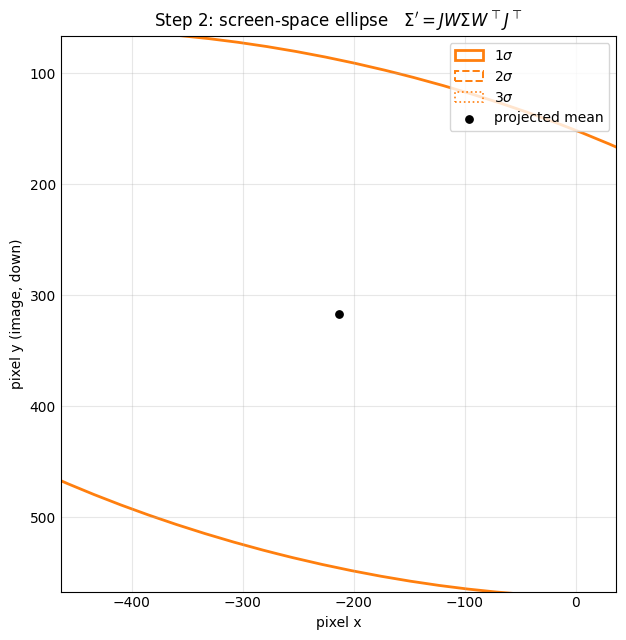

In [18]:
from matplotlib.patches import Ellipse

print("=" * 78)
print("Cell 3: Step 2 — 2D screen projection   Sigma' = J W Sigma W^T J^T")
print("=" * 78)

# Camera view matrix: PyTorch stores world_view_transform as W2V.T (row vectors).
# The paper / CUDA use column vectors: p_view = W2V @ p_world.
W_4x4 = viewpoint_cam.world_view_transform.detach().cpu().numpy().T
W_3x3 = W_4x4[:3, :3]

print("\n--- View matrix W (4x4), world-to-view, column-vector convention ---")
print(W_4x4)
print(f"shape = {W_4x4.shape}")

print("\n--- Linear part W (3x3) used in Sigma' = J W Sigma W^T J^T ---")
print(W_3x3)

mean_h = np.append(xyz_np, 1.0)
t_view = W_4x4 @ mean_h
tx, ty, tz = t_view[:3]
print("\n--- Camera-space mean t = W @ [xyz, 1] ---")
print(f"t_view (4,) = {t_view}")
print(f"t = (x, y, z) = ({tx:.6f}, {ty:.6f}, {tz:.6f})")

tanfovx = math.tan(viewpoint_cam.FoVx * 0.5)
tanfovy = math.tan(viewpoint_cam.FoVy * 0.5)
height = int(viewpoint_cam.image_height)
width = int(viewpoint_cam.image_width)
focal_x = width / (2.0 * tanfovx)
focal_y = height / (2.0 * tanfovy)
print("\n--- Intrinsics ---")
print(f"image size = {width} x {height}")
print(f"FoVx = {float(viewpoint_cam.FoVx):.6f} rad, FoVy = {float(viewpoint_cam.FoVy):.6f} rad")
print(f"tanfovx = {tanfovx:.6f}, tanfovy = {tanfovy:.6f}")
print(f"focal_x = {focal_x:.6f}, focal_y = {focal_y:.6f}")

# Near-plane clamp used by the official CUDA rasterizer
limx, limy = 1.3 * tanfovx, 1.3 * tanfovy
tx_c = np.clip(tx / tz, -limx, limx) * tz
ty_c = np.clip(ty / tz, -limy, limy) * tz

# Jacobian of the affine approximation of projection (paper: 2x3)
J = np.array([
    [focal_x / tz, 0.0,          -focal_x * tx_c / (tz * tz)],
    [0.0,          focal_y / tz, -focal_y * ty_c / (tz * tz)],
], dtype=np.float64)

print("\n--- Jacobian J (2x3) ---")
print("J = [[ fx/z,    0,   -fx*x/z^2 ],")
print("     [    0, fy/z,   -fy*y/z^2 ]]")
print(J)
print(f"shape = {J.shape}")

print("\n--- Intermediate 3x3:  W Sigma W^T ---")
WSW = W_3x3 @ Sigma @ W_3x3.T
print(WSW)
print(f"shape = {WSW.shape}")

print("\n--- 2D screen-space covariance  Sigma' = J (W Sigma W^T) J^T  (2x2) ---")
Sigma_prime = J @ WSW @ J.T
print(Sigma_prime)
print(f"shape = {Sigma_prime.shape}")
print(f"symmetric? max |Sigma' - Sigma'^T| = {np.abs(Sigma_prime - Sigma_prime.T).max():.3e}")

evals, evecs = np.linalg.eigh(Sigma_prime)
order = np.argsort(evals)[::-1]
evals = np.clip(evals[order], 1e-12, None)
evecs = evecs[:, order]
sigma_axes = np.sqrt(evals)
print(f"eigenvalues of Sigma' = {evals}")
print(f"1-sigma ellipse axes (sqrt(eig)) = {sigma_axes[0]:.6f} x {sigma_axes[1]:.6f} px")

# Project xyz to pixel coordinates (ndc2Pix)
full_proj = viewpoint_cam.full_proj_transform.detach().cpu().numpy().T
p_hom = full_proj @ mean_h
p_ndc = p_hom[:3] / (p_hom[3] + 1e-7)
mean2d = np.array([
    ((p_ndc[0] + 1.0) * width - 1.0) * 0.5,
    ((p_ndc[1] + 1.0) * height - 1.0) * 0.5,
])
print("\n--- Projected 2D mean (pixels) ---")
print(f"p_hom = {p_hom}")
print(f"p_ndc = {p_ndc}")
print(f"mean2d (x, y) = ({mean2d[0]:.6f}, {mean2d[1]:.6f})")

radius = int(np.ceil(3.0 * sigma_axes[0]))
patch_r = int(np.clip(radius, 16, 250))
angle_deg = np.degrees(np.arctan2(evecs[1, 0], evecs[0, 0]))

fig, ax = plt.subplots(figsize=(6.5, 6.5))
for n_sig, ls, lw in [(1, "-", 2.0), (2, "--", 1.4), (3, ":", 1.2)]:
    ax.add_patch(Ellipse(
        xy=mean2d,
        width=2 * n_sig * sigma_axes[0],
        height=2 * n_sig * sigma_axes[1],
        angle=angle_deg,
        fill=False, ec="tab:orange", ls=ls, lw=lw,
        label=fr"{n_sig}$\sigma$",
    ))
ax.scatter([mean2d[0]], [mean2d[1]], c="k", s=28, zorder=5, label="projected mean")
ax.set_xlim(mean2d[0] - patch_r, mean2d[0] + patch_r)
ax.set_ylim(mean2d[1] + patch_r, mean2d[1] - patch_r)
ax.set_aspect("equal")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y (image, down)")
ax.set_title(r"Step 2: screen-space ellipse   $\Sigma' = J W \Sigma W^{\top} J^{\top}$")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()
print("=" * 78)


Cell 4: Step 3 — 2D rasterization   G(x) = exp(-1/2 x^T Sigma'^{-1} x)

--- Inverse 2D covariance  Sigma'^{-1}  (2x2) ---
[[ 0.000004 -0.000004]
 [-0.000004  0.000019]]
shape = (2, 2)

--- Determinant ---
det(Sigma')     = 15151809828.39149094
det(Sigma'^-1)  = 0.00000000
product (should be 1) = 1.00000000

Formula:
  G(x)     = exp(-1/2 * x^T Sigma'^{-1} x)
  alpha(x) = o * G(x)   (clamped to 0.99, matching the rasterizer)
  o = 0.79697728

--- Example pixels  x = pixel - mean2d ---

  [projected mean (offset 0)]
    pixel coordinate     = (-213.6745, 316.7700)
    offset vector x      = [0. 0.]
    x^T Sigma'^-1 x     = 0.00000000
    exponent -1/2 that   = -0.00000000
    G(x)                 = 1.00000000
    alpha(x) = o * G(x)  = 0.79697728

  [1 pixel to the right]
    pixel coordinate     = (-212.6745, 316.7700)
    offset vector x      = [1. 0.]
    x^T Sigma'^-1 x     = 0.00000429
    exponent -1/2 that   = -0.00000215
    G(x)                 = 0.99999785
    alpha(x) = o * G

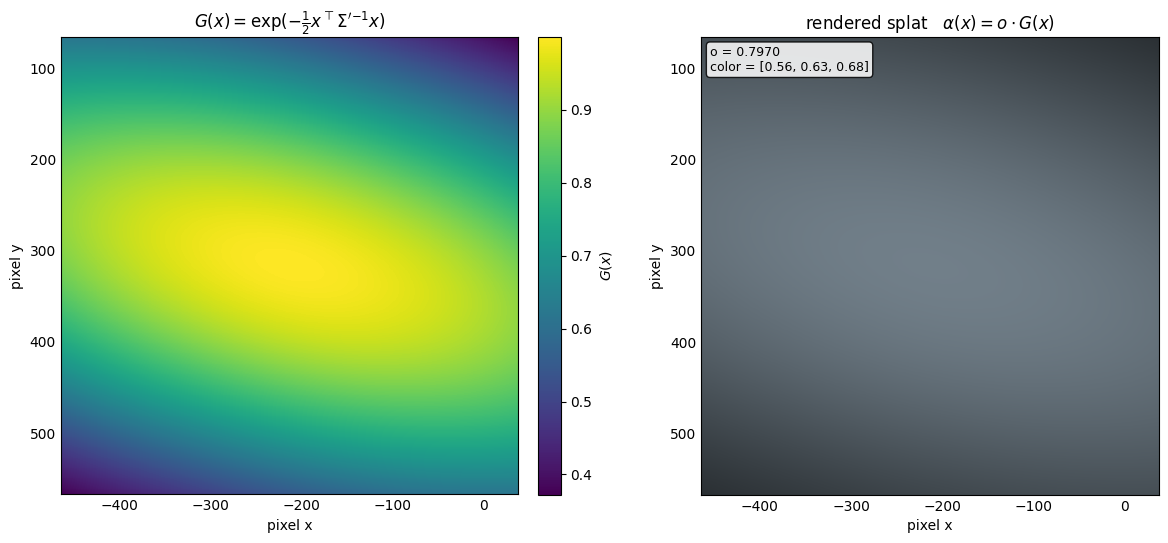

Training progress:   2%|▏         | 600/30000 [00:30<13:50, 35.42it/s, Loss=0.0931000, Depth Loss=0.0000000]

In [19]:
print("=" * 78)
print("Cell 4: Step 3 — 2D rasterization   G(x) = exp(-1/2 x^T Sigma'^{-1} x)")
print("=" * 78)

Sigma_prime_inv = np.linalg.inv(Sigma_prime)
det_sp = float(np.linalg.det(Sigma_prime))

print("\n--- Inverse 2D covariance  Sigma'^{-1}  (2x2) ---")
print(Sigma_prime_inv)
print(f"shape = {Sigma_prime_inv.shape}")

print("\n--- Determinant ---")
print(f"det(Sigma')     = {det_sp:.8f}")
print(f"det(Sigma'^-1)  = {float(np.linalg.det(Sigma_prime_inv)):.8f}")
print(f"product (should be 1) = {det_sp * float(np.linalg.det(Sigma_prime_inv)):.8f}")

print("\nFormula:")
print("  G(x)     = exp(-1/2 * x^T Sigma'^{-1} x)")
print("  alpha(x) = o * G(x)   (clamped to 0.99, matching the rasterizer)")
print(f"  o = {opacity_o_f:.8f}")

def mahalanobis2(x_vec):
    return float(x_vec @ Sigma_prime_inv @ x_vec)

def eval_G(x_vec):
    m2 = mahalanobis2(x_vec)
    G_val = math.exp(-0.5 * m2)
    alpha_val = min(0.99, opacity_o_f * G_val)
    return m2, G_val, alpha_val

# Sample pixels: center, 1px offset, 1-sigma along major axis, 3-sigma
samples = {
    "projected mean (offset 0)": np.array([0.0, 0.0]),
    "1 pixel to the right": np.array([1.0, 0.0]),
    "1-sigma along major axis": evecs[:, 0] * sigma_axes[0],
    "3-sigma along major axis": evecs[:, 0] * 3.0 * sigma_axes[0],
}

print("\n--- Example pixels  x = pixel - mean2d ---")
for name, x_vec in samples.items():
    m2, G_val, alpha_val = eval_G(x_vec)
    pix = mean2d + x_vec
    print(f"\n  [{name}]")
    print(f"    pixel coordinate     = ({pix[0]:.4f}, {pix[1]:.4f})")
    print(f"    offset vector x      = {x_vec}")
    print(f"    x^T Sigma'^-1 x     = {m2:.8f}")
    print(f"    exponent -1/2 that   = {-0.5 * m2:.8f}")
    print(f"    G(x)                 = {G_val:.8f}")
    print(f"    alpha(x) = o * G(x)  = {alpha_val:.8f}")

# Evaluate G(x) on a pixel grid around the projected mean
xs = np.arange(np.floor(mean2d[0] - patch_r), np.ceil(mean2d[0] + patch_r) + 1)
ys = np.arange(np.floor(mean2d[1] - patch_r), np.ceil(mean2d[1] + patch_r) + 1)
xx, yy = np.meshgrid(xs, ys)
dx = xx - mean2d[0]
dy = yy - mean2d[1]
power = -0.5 * (
    Sigma_prime_inv[0, 0] * dx * dx
    + 2.0 * Sigma_prime_inv[0, 1] * dx * dy
    + Sigma_prime_inv[1, 1] * dy * dy
)
G = np.exp(np.clip(power, -80.0, 0.0))
alpha = np.clip(opacity_o_f * G, 0.0, 0.99)
rgb_patch = alpha[..., None] * rgb_color[None, None, :]

print("\n--- Rasterized patch stats ---")
print(f"patch size (W x H) = {alpha.shape[1]} x {alpha.shape[0]}")
print(f"max G(x)     = {G.max():.8f}")
print(f"max alpha(x) = {alpha.max():.8f}")
print(f"rgb_color    = {rgb_color}")

extent = [xs.min() - 0.5, xs.max() + 0.5, ys.max() + 0.5, ys.min() - 0.5]
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

im0 = axes[0].imshow(G, extent=extent, cmap="viridis", origin="upper", interpolation="nearest")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label=r"$G(x)$")
axes[0].set_title(r"$G(x)=\exp(-\frac{1}{2} x^{\top} \Sigma'^{-1} x)$")
axes[0].set_xlabel("pixel x")
axes[0].set_ylabel("pixel y")

axes[1].imshow(np.clip(rgb_patch, 0, 1), extent=extent, origin="upper", interpolation="nearest")
axes[1].set_title(r"rendered splat   $\alpha(x)=o\cdot G(x)$")
axes[1].set_xlabel("pixel x")
axes[1].set_ylabel("pixel y")
axes[1].text(
    0.02, 0.98,
    f"o = {opacity_o_f:.4f}\ncolor = [{rgb_color[0]:.2f}, {rgb_color[1]:.2f}, {rgb_color[2]:.2f}]",
    transform=axes[1].transAxes, va="top", ha="left", fontsize=9,
    bbox=dict(boxstyle="round", fc="white", alpha=0.85),
)

for ax in axes:
    ax.tick_params(length=0)
plt.tight_layout()
plt.show()
print("=" * 78)
